# GIRA2005HSCC: reachable sets of linear systems with zonotopes

Girard, A. (2005). Reachability of uncertain linear systems using zonotopes. *HSCC 2005*, pp. 291-305.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ASAG-ISCAS/PyBDR/blob/master/examples/gira2005hscc.ipynb)

Each case is independent. Some cases run for several minutes; the outputs stored in this notebook show the results without running it.

In [1]:
# install PyBDR when running on Colab (skipped when it is already installed)
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pybdr") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "pybdr @ git+https://github.com/ASAG-ISCAS/PyBDR"])

In [2]:
%matplotlib inline

import numpy as np
from pybdr.geometry import Zonotope, Geometry, Interval
from pybdr.geometry.operation import cvt2, boundary
from pybdr.dynamic_system import LinSys
from pybdr.algorithm import GIRA2005HSCC
from pybdr.util.visualization import plot, plot_cmp
from pybdr.util.functional import performance_counter, performance_counter_start

## Reach linear zono algo3 case 00

`t_end = 5`, `step = 0.01`, boundary analysis (`reach_parallel`)

12


reach_linear_zono_algo3_parallel cost: 1.7241405830000003s
502


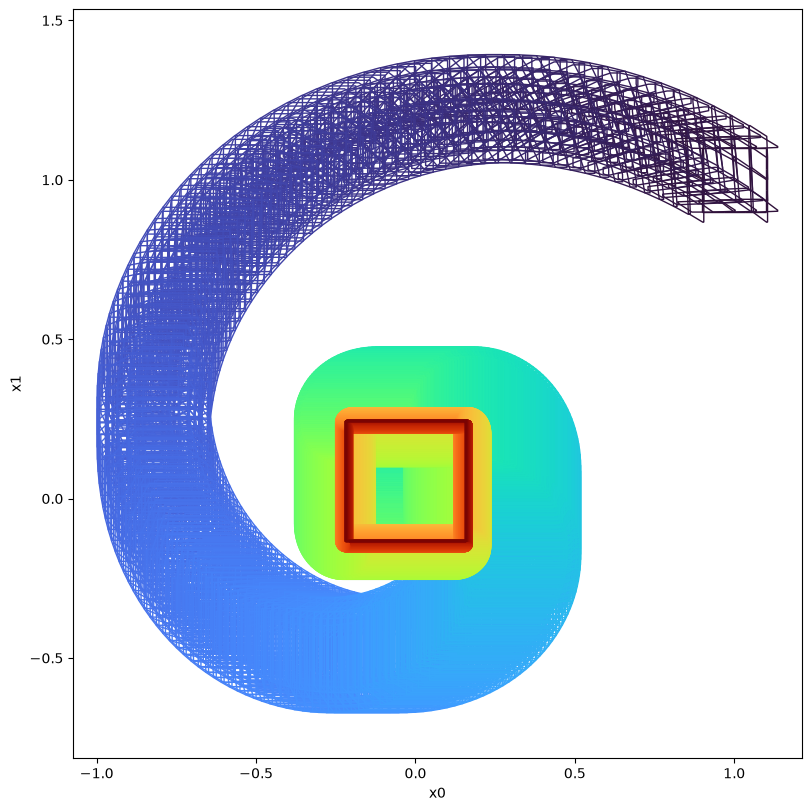

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x0', ylabel='x1'>)

In [3]:
time_tag = performance_counter_start()

xa = [[-1, -4], [4, -1]]
ub = np.array([[1], [1]])

lin_sys = LinSys(xa, ub)
opts = GIRA2005HSCC.Options()
opts.t_end = 5
opts.step = 0.01
opts.eta = 4
# opts.x0 = cvt2(Interval([0.9, 0.9], [1.1, 1.1]), Geometry.TYPE.ZONOTOPE)
x0 = Interval([0.9, 0.9], [1.1, 1.1])
opts.u = cvt2(ub @ Interval(0.01, 0.3), Geometry.TYPE.ZONOTOPE)  # u must contain origin
x0_bounds = boundary(x0, 0.1, Geometry.TYPE.ZONOTOPE)

print(len(x0_bounds))

_, ri, _, _ = GIRA2005HSCC.reach_parallel(lin_sys, opts, x0_bounds)

performance_counter(time_tag, "reach_linear_zono_algo3_parallel")

print(len(ri))

plot(ri, [0, 1])

## Reach linear zono algo3 case 01

`t_end = 5`, `step = 0.04`, boundary analysis (`reach_parallel`)

In [4]:
time_tag = performance_counter_start()

xa = np.array([[-1, -4, 0, 0, 0], [4, - 1, 0, 0, 0], [0, 0, -3, 1, 0], [0, 0, -1, -3, 0], [0, 0, 0, 0, -2]])
ub = np.eye(5)

lin_sys = LinSys(xa, ub)
opts = GIRA2005HSCC.Options()
opts.t_end = 5
opts.step = 0.04
opts.eta = 4
x0 = Interval(0.9 * np.ones(5), 1.1 * np.ones(5))
u = Interval([0.9, -0.25, -0.1, 0.25, -0.75], [1.1, 0.25, 0.1, 0.75, -0.25])
opts.u = cvt2(ub @ u, Geometry.TYPE.ZONOTOPE)  # this case is special because u does not contain origin

x0_bounds = boundary(x0, 0.1, Geometry.TYPE.ZONOTOPE)

performance_counter(time_tag, "boundary")

print(len(x0_bounds))

_, ri, _, _ = GIRA2005HSCC.reach_parallel(lin_sys, opts, x0_bounds)

performance_counter(time_tag, "reach_linear_zono_algo3_parallel")

boundary cost: 0.004778166s
810


reach_linear_zono_algo3_parallel cost: 3.0788067080000006s


68437741988208

## Reach linear zono algo3 case 02

`t_end = 5`, `step = 0.01`, boundary analysis (`reach_parallel`)

boundary cost: 0.0010227500000000002s
10


reach_linear_zono_algo3_parallel cost: 2.0741677920000003s


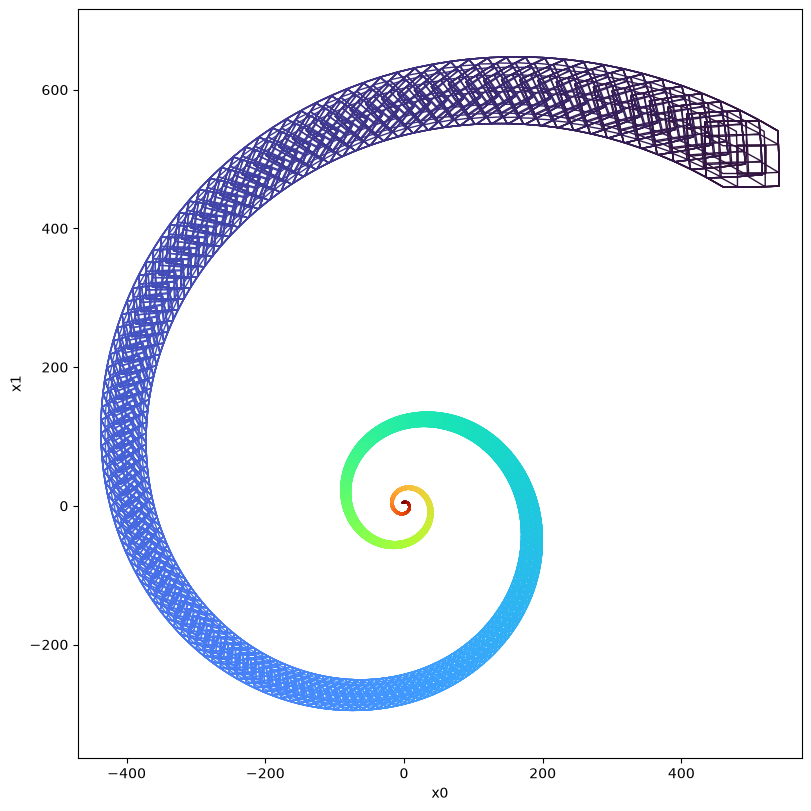

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x0', ylabel='x1'>)

In [5]:
time_tag = performance_counter_start()

xa = np.array([[-1, -4, 0, 0, 0], [4, - 1, 0, 0, 0], [0, 0, -3, 1, 0], [0, 0, -1, -3, 0], [0, 0, 0, 0, -2]])
ub = np.eye(5)

lin_sys = LinSys(xa, ub)
opts = GIRA2005HSCC.Options()
opts.t_end = 5
opts.step = 0.01
opts.eta = 4
x0 = Interval(0.9 * np.ones(5), 1.1 * np.ones(5))
x0 = Interval(480 * np.ones(5), 520 * np.ones(5))
u = Interval([0.9, -0.25, -0.1, 0.25, -0.75], [1.1, 0.25, 0.1, 0.75, -0.25])
opts.u = cvt2(ub @ u, Geometry.TYPE.ZONOTOPE)  # this case is special because u does not contain origin

x0_bounds = boundary(x0, 400, Geometry.TYPE.ZONOTOPE)

# print(len(x0_bounds))

performance_counter(time_tag, "boundary")

print(len(x0_bounds))

_, ri, _, _ = GIRA2005HSCC.reach_parallel(lin_sys, opts, x0_bounds)

performance_counter(time_tag, "reach_linear_zono_algo3_parallel")

plot(ri, [0, 1])

## Reach linear zono algo3 parallel case 03

`t_end = 5`, `step = 0.1`, boundary analysis (`reach_parallel`)

8
reach_linear_zono_algo3_parallel_reach_whole cost: 0.002482792s


reach_linear_zono_algo3_parallel_bound cost: 1.5189664170000001s


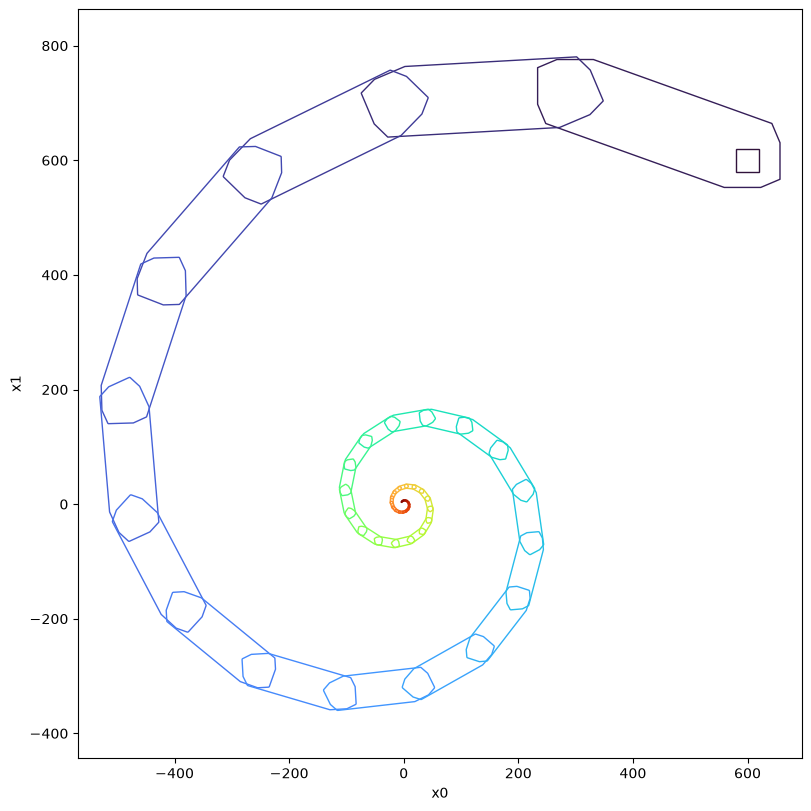

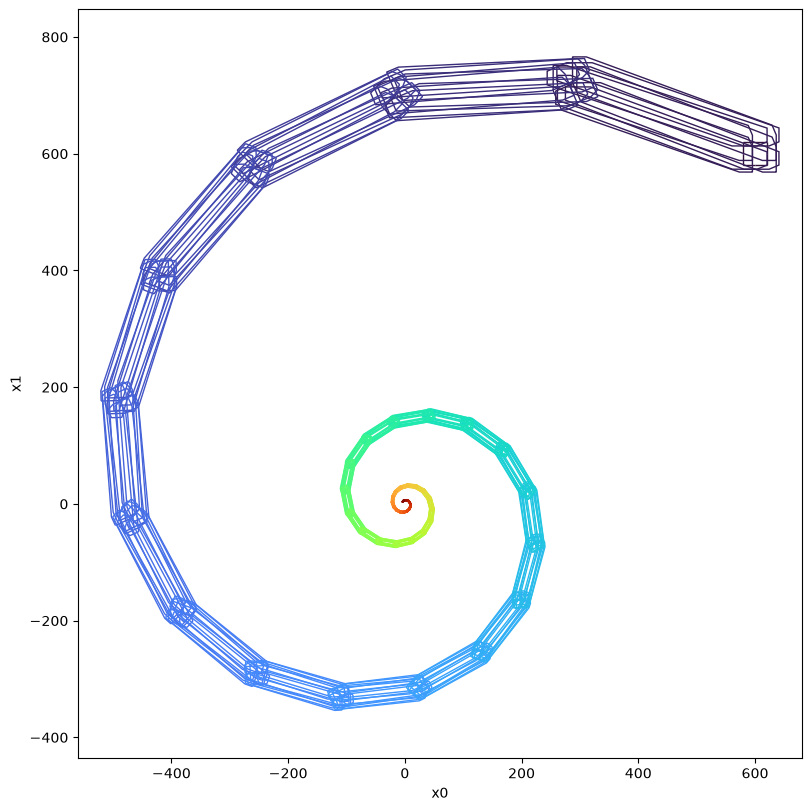

52
52


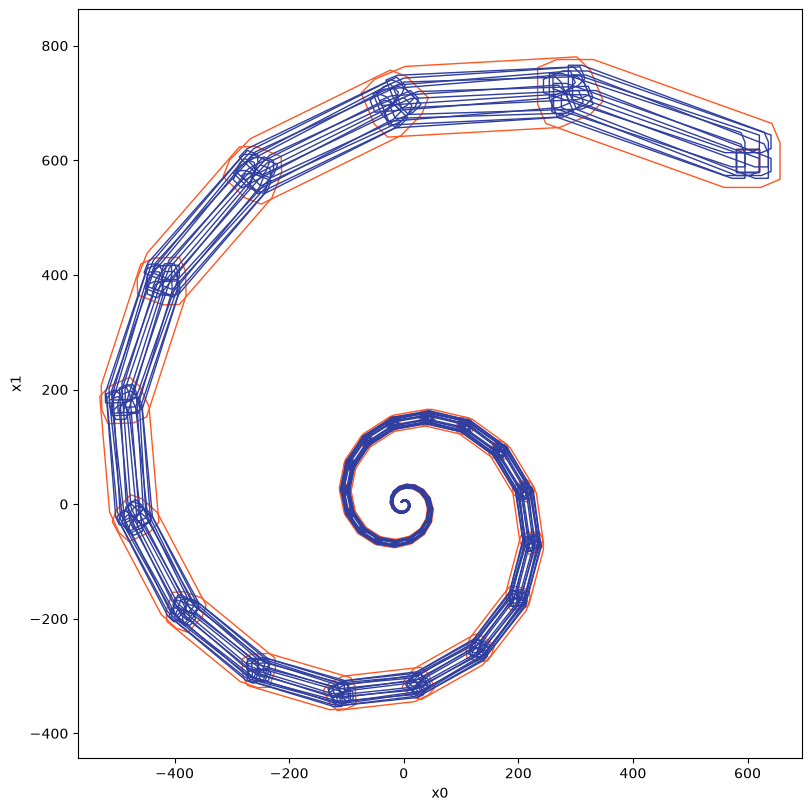

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x0', ylabel='x1'>)

In [6]:
time_tag = performance_counter_start()

xa = [[-1, -4], [4, -1]]
ub = np.array([[1], [1]])

lin_sys = LinSys(xa, ub)
opts = GIRA2005HSCC.Options()
opts.t_end = 5
opts.step = 0.1
opts.eta = 4
# opts.x0 = cvt2(Interval([0.9, 0.9], [1.1, 1.1]), Geometry.TYPE.ZONOTOPE)
# x0 = Interval([0.9, 0.9], [1.1, 1.1])
x0 = Interval(580 * np.ones(2), 620 * np.ones(2))
opts.u = cvt2(ub @ Interval(0.1, 0.3), Geometry.TYPE.ZONOTOPE)  # u must contain origin
x0_bounds = boundary(x0, 40, Geometry.TYPE.ZONOTOPE)

# plot([x0, *x0_bounds], [0, 1])

print(len(x0_bounds))

_, ri_whole, _, _ = GIRA2005HSCC.reach(lin_sys, opts, cvt2(x0, Geometry.TYPE.ZONOTOPE))

performance_counter(time_tag, "reach_linear_zono_algo3_parallel_reach_whole")

_, ri, _, _ = GIRA2005HSCC.reach_parallel(lin_sys, opts, x0_bounds)

performance_counter(time_tag, "reach_linear_zono_algo3_parallel_bound")

plot(ri_whole, [0, 1])
plot(ri, [0, 1])

print(len(ri))
print(len(ri_whole))

ri.append([x0])
ri_whole.append(x0)

# print(len(ri))

vis_pts = []

plot_cmp([ri_whole, ri], [0, 1], cs=["#FF5722", "#303F9F"])

## Reach linear zono algo3 bound demo

`t_end = 0.1`, `step = 0.1`, boundary analysis (`reach_parallel`)

8


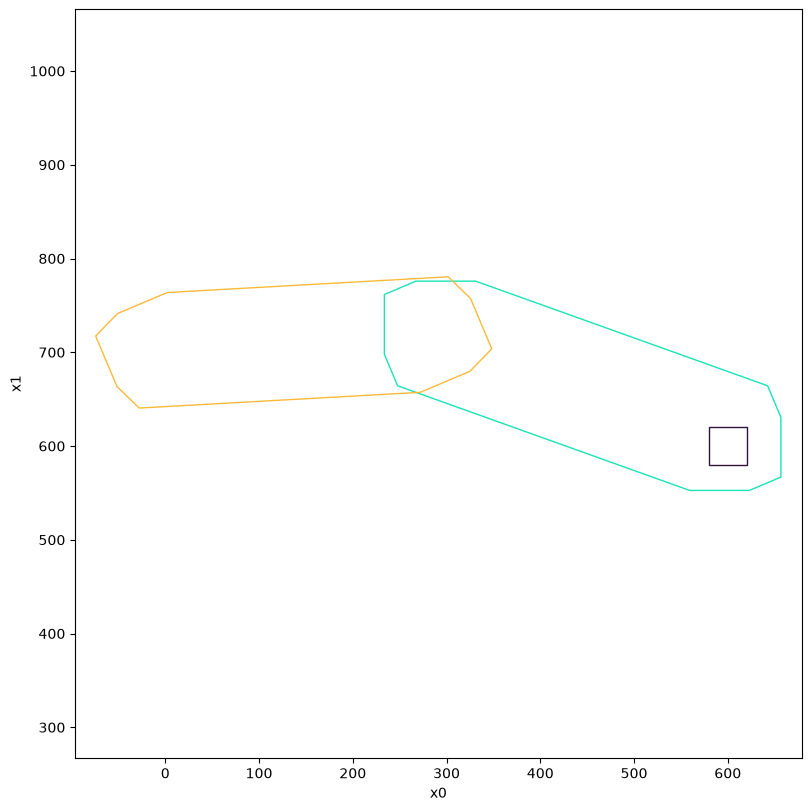

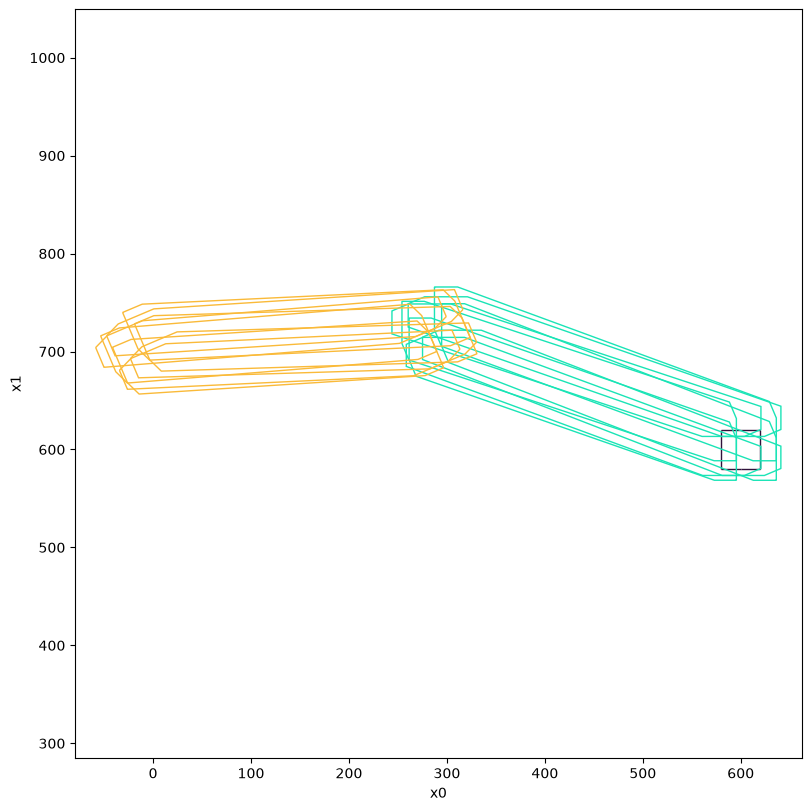

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x0', ylabel='x1'>)

In [7]:
xa = [[-1, -4], [4, -1]]
ub = np.array([[1], [1]])

lin_sys = LinSys(xa, ub)
opts = GIRA2005HSCC.Options()
opts.t_end = 0.1
opts.step = 0.1
opts.eta = 4

x0 = Interval(580 * np.ones(2), 620 * np.ones(2))
opts.u = cvt2(ub @ Interval(0.1, 0.3), Geometry.TYPE.ZONOTOPE)  # u must contain origin
x0_bounds = boundary(x0, 40, Geometry.TYPE.ZONOTOPE)

print(len(x0_bounds))

_, ri_whole, _, _ = GIRA2005HSCC.reach(lin_sys, opts, cvt2(x0, Geometry.TYPE.ZONOTOPE))

_, ri, _, _ = GIRA2005HSCC.reach_parallel(lin_sys, opts, x0_bounds)

plot(ri_whole, [0, 1])
plot(ri, [0, 1])

## Reach linear zono algo3 parallel case 04

`t_end = 5`, `step = 0.01`, boundary analysis (`reach_parallel`)

The number of divided sets:  160


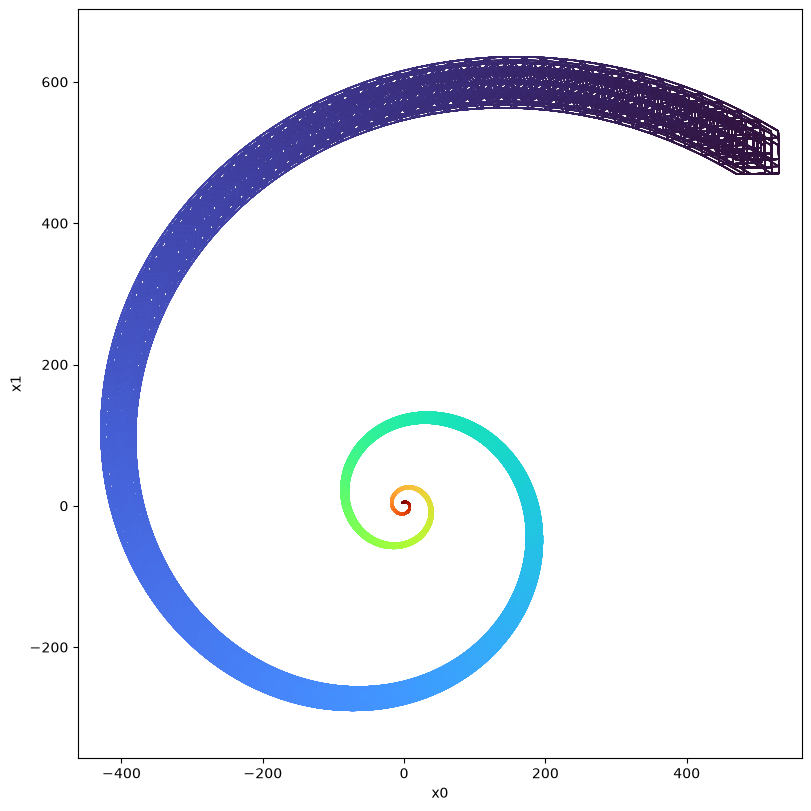

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x0', ylabel='x1'>)

In [8]:
xa = np.array([[-1, -4, 0, 0, 0], [4, -1, 0, 0, 0], [0, 0, -3, 1, 0], [0, 0, -1, -3, 0], [0, 0, 0, 0, -2]])
ub = np.eye(5)

lin_sys = LinSys(xa, ub)
opts = GIRA2005HSCC.Options()
opts.t_end = 5
opts.step = 0.01
opts.eta = 4
x0 = Interval(480 * np.ones(5), 520 * np.ones(5))

u = Interval([0.9, -0.25, -0.1, 0.25, -0.75], [1.1, 0.25, 0.1, 0.75, -0.25])
opts.u = cvt2(ub @ u, Geometry.TYPE.ZONOTOPE)  # this case is special because u does not contain origin

x0_bounds = boundary(x0, 40, Geometry.TYPE.ZONOTOPE)
print("The number of divided sets: ", len(x0_bounds))

unsafe_set = Interval([0.9, -0.25, -0.1, 0.25, -0.75], [1.1, 0.25, 0.1, 0.75, -0.25])
_, ri, _, _ = GIRA2005HSCC.reach_parallel(lin_sys, opts, x0_bounds)

plot(ri, [0, 1])

## Reach linear zono algo3 parallel case 05

`t_end = 4`, `step = 0.01`, boundary analysis (`reach_parallel`)

28


reach_linear_zono_algo3_parallel cost: 2.7563883330000003s
402


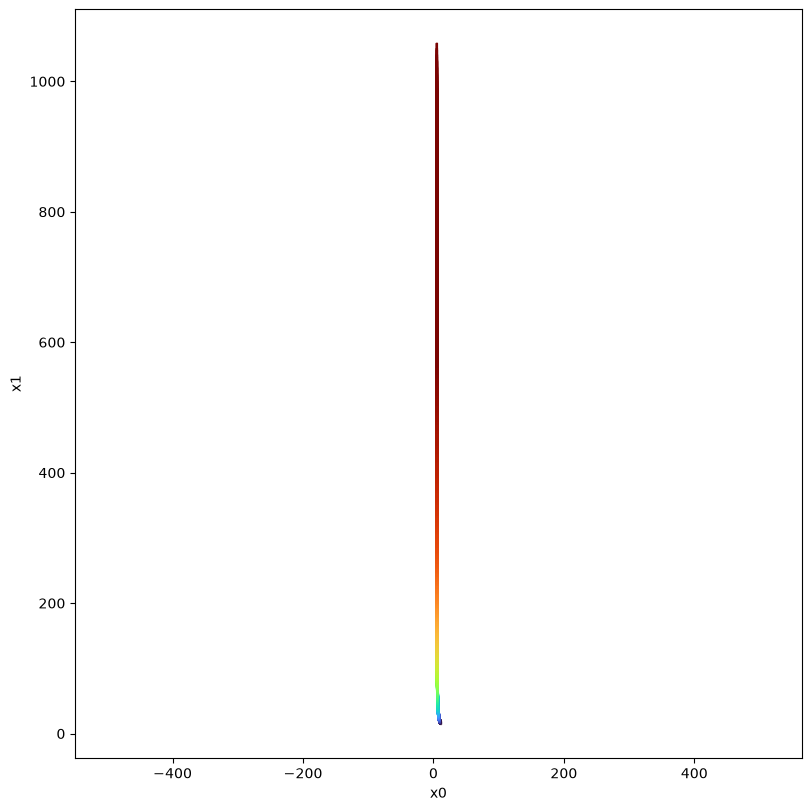

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x0', ylabel='x1'>)

In [9]:
time_tag = performance_counter_start()

xa = [[-1, 0], [-1, 1]]
ub = np.array([[1], [1]])

lin_sys = LinSys(xa, ub)
opts = GIRA2005HSCC.Options()
opts.t_end = 4
opts.step = 0.01
opts.eta = 4
# opts.x0 = cvt2(Interval([0.9, 0.9], [1.1, 1.1]), Geometry.TYPE.ZONOTOPE)
# x0 = Interval([0.9, 0.9], [1.1, 1.1]) * 10
x0 = Interval([10, 15], [11, 20])
opts.u = cvt2(ub @ Interval(0.01, 0.3), Geometry.TYPE.ZONOTOPE)  # u must contain origin
opts.u = Zonotope(5 * np.ones(2), np.eye(2))
x0_bounds = boundary(x0, 0.5, Geometry.TYPE.ZONOTOPE)

print(len(x0_bounds))

_, ri, _, _ = GIRA2005HSCC.reach_parallel(lin_sys, opts, x0_bounds)

performance_counter(time_tag, "reach_linear_zono_algo3_parallel")

print(len(ri))

plot(ri, [0, 1])